# ERC Accessibility Forecasting

## Question

Can present operational observables predict future accessibility deterioration under perturbation–recovery constraints?

## Objective

This notebook builds on the Dynamic Accessibility Lattice framework.

The goal is to test whether accessibility-related observables measured at time `t` contain predictive information about future accessibility contraction at `t + Δt`.

This is an exploratory forecasting extension, not a fitted empirical model.

In [26]:
# ============================================================
# ERC Accessibility Forecasting — setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"

for folder in [DATA_DIR, FIG_DIR]:
    folder.mkdir(exist_ok=True)

np.random.seed(42)

print("ERC Accessibility Forecasting notebook ready")

ERC Accessibility Forecasting notebook ready


## 1. Minimal DAL model
Operational simulation framework used to generate recoverability dynamics.

In [27]:
# ============================================================
# Base DAL functions
# ============================================================

GRID_SIZE = 12

G = nx.grid_2d_graph(GRID_SIZE, GRID_SIZE)
G = nx.convert_node_labels_to_integers(G)

pos = {
    node: (node % GRID_SIZE, node // GRID_SIZE)
    for node in G.nodes()
}

N = G.number_of_nodes()


def initialize_state(N):
    return {
        "r": np.ones(N),
        "D": np.zeros(N),
    }


def perturbation_profile(G, center_node, radius=3):
    lengths = nx.single_source_shortest_path_length(
        G,
        center_node,
        cutoff=radius
    )

    affected = np.zeros(G.number_of_nodes())

    for node, dist in lengths.items():
        affected[node] = np.exp(-dist)

    return affected


def update_state(
    state,
    perturbation,
    alpha=0.20,
    beta=0.03,
    gamma=0.12,
    decay=0.01,
    dt=1.0
):
    r = state["r"].copy()
    D = state["D"].copy()

    dr = (
        -alpha * perturbation
        + beta * (1 - r)
        - gamma * D
    )

    dD = (
        perturbation
        - decay * D
    )

    r = np.clip(r + dr * dt, 0, 1)
    D = np.clip(D + dD * dt, 0, None)

    return {
        "r": r,
        "D": D
    }


def edge_traversability(G, r, D):
    weights = {}

    for u, v in G.edges():
        local_capacity = 0.5 * (r[u] + r[v])
        local_burden = 0.5 * (D[u] + D[v])

        w = local_capacity / (1 + local_burden)
        weights[(u, v)] = w

    return weights


def weighted_effective_graph(G, weights, epsilon=0.05):
    Gw = nx.Graph()
    Gw.add_nodes_from(G.nodes())

    for (u, v), w in weights.items():

        cost = 1.0 / (w + epsilon)

        Gw.add_edge(
            u,
            v,
            traversability=w,
            cost=cost
        )

    return Gw


def effective_graph(G, weights, threshold=0.65):
    Ge = nx.Graph()
    Ge.add_nodes_from(G.nodes())

    for (u, v), w in weights.items():
        if w >= threshold:
            Ge.add_edge(u, v, weight=w)

    return Ge


def accessibility_metrics(G, Ge, source_node=0):
    structural_reachable = len(nx.node_connected_component(G, source_node))

    if source_node in Ge:
        effective_reachable = len(nx.node_connected_component(Ge, source_node))
    else:
        effective_reachable = 0

    return {
        "reachable_fraction": effective_reachable / structural_reachable,
        "effective_edges": Ge.number_of_edges(),
        "edge_fraction": Ge.number_of_edges() / G.number_of_edges(),
    }


def weighted_cost_metrics(G, Gw, source_node=0):
    path_costs = nx.single_source_dijkstra_path_length(
        Gw,
        source_node,
        weight="cost"
    )

    costs = np.array(list(path_costs.values()))

    return {
        "weighted_mean_path_cost": np.mean(costs),
        "weighted_max_path_cost": np.max(costs),
        "weighted_efficiency": np.mean(1 / (costs + 1)),
    }

In [28]:
# ============================================================
# Run one temporal DAL simulation
# ============================================================

def generate_schedule(start=10, interval=10, n_events=5):
    return [start + i * interval for i in range(n_events)]


def run_temporal_scenario(
    simulation_id,
    interval,
    beta,
    gamma,
    decay,
    perturbation_strength=3.0,
    T=140,
    alpha=0.20,
    access_threshold=0.65,
    source_node=0,
    noise=False
):
    center_node = N // 2
    state = initialize_state(N)

    schedule = generate_schedule(
        start=10,
        interval=interval,
        n_events=5
    )

    records = []

    for t in range(T):

        perturbation_scale = 1.0

        if noise:
            perturbation_scale = np.clip(
                np.random.normal(1.0, 0.10),
                0.75,
                1.25
            )

        if t in schedule:
            P = (
                perturbation_scale
                * perturbation_strength
                * perturbation_profile(
                    G,
                    center_node=center_node,
                    radius=3
                )
            )
        else:
            P = np.zeros(N)

        state = update_state(
            state,
            P,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            decay=decay,
            dt=1.0
        )

        weights = edge_traversability(
            G,
            state["r"],
            state["D"]
        )

        Ge = effective_graph(
            G,
            weights,
            threshold=access_threshold
        )

        Gw = weighted_effective_graph(
            G,
            weights,
            epsilon=0.05
        )

        binary_metrics = accessibility_metrics(
            G,
            Ge,
            source_node=source_node
        )

        weighted_metrics = weighted_cost_metrics(
            G,
            Gw,
            source_node=source_node
        )

        records.append({
            "simulation_id": simulation_id,
            "time": t,
            "interval": interval,
            "perturbation_density": 1 / interval,
            "recovery_beta": beta,
            "gamma": gamma,
            "decay": decay,
            "noise": noise,
            "mean_r": np.mean(state["r"]),
            "min_r": np.min(state["r"]),
            "mean_D": np.mean(state["D"]),
            "max_D": np.max(state["D"]),
            **binary_metrics,
            **weighted_metrics,
        })

    return pd.DataFrame(records)

## 2. Temporal forecasting dataset
Generate temporal trajectories and forecasting targets.

In [29]:
# ============================================================
# Generate temporal forecasting dataset
# ============================================================

interval_axis = np.array([4, 6, 8, 10, 12, 16, 20, 25, 30])
recovery_axis = np.linspace(0.012, 0.060, 9)

all_runs = []
simulation_id = 0

for interval in interval_axis:

    for beta in recovery_axis:

        gamma_case = 0.18 - beta
        decay_case = beta / 3

        df_run = run_temporal_scenario(
            simulation_id=simulation_id,
            interval=interval,
            beta=beta,
            gamma=gamma_case,
            decay=decay_case,
            perturbation_strength=3.0,
            T=140,
            access_threshold=0.65,
            noise=False
        )

        all_runs.append(df_run)
        simulation_id += 1

temporal_df = pd.concat(
    all_runs,
    ignore_index=True
)

temporal_df.to_csv(
    DATA_DIR / "dal_temporal_forecasting_raw.csv",
    index=False
)

temporal_df.head()

,simulation_id,time,interval,perturbation_density,recovery_beta,gamma,decay,noise,mean_r,min_r,mean_D,max_D,reachable_fraction,effective_edges,edge_fraction,weighted_mean_path_cost,weighted_max_path_cost,weighted_efficiency
0,0,0,4,0.25,0.012,0.168,0.004,False,1.0,1.0,0.0,0.0,1.0,264,1.0,10.47619,20.952381,0.11653
1,0,1,4,0.25,0.012,0.168,0.004,False,1.0,1.0,0.0,0.0,1.0,264,1.0,10.47619,20.952381,0.11653
2,0,2,4,0.25,0.012,0.168,0.004,False,1.0,1.0,0.0,0.0,1.0,264,1.0,10.47619,20.952381,0.11653
3,0,3,4,0.25,0.012,0.168,0.004,False,1.0,1.0,0.0,0.0,1.0,264,1.0,10.47619,20.952381,0.11653
4,0,4,4,0.25,0.012,0.168,0.004,False,1.0,1.0,0.0,0.0,1.0,264,1.0,10.47619,20.952381,0.11653


In [30]:
# ============================================================
# Create future deterioration target
# state(t) -> deterioration(t + forecast_horizon)
# ============================================================

FORECAST_HORIZON = 20

forecast_df = temporal_df.copy()

forecast_df["future_weighted_efficiency"] = (
    forecast_df
    .groupby("simulation_id")["weighted_efficiency"]
    .shift(-FORECAST_HORIZON)
)

forecast_df["future_reachable_fraction"] = (
    forecast_df
    .groupby("simulation_id")["reachable_fraction"]
    .shift(-FORECAST_HORIZON)
)

# Future deterioration target:
# 1 if future efficiency is lower than current efficiency by threshold
EFFICIENCY_DROP_THRESHOLD = 0.002

forecast_df["future_deterioration"] = (
    (
        forecast_df["weighted_efficiency"]
        - forecast_df["future_weighted_efficiency"]
    )
    > EFFICIENCY_DROP_THRESHOLD
).astype(int)

# Remove rows without future horizon
forecast_df = forecast_df.dropna().reset_index(drop=True)

forecast_df.to_csv(
    DATA_DIR / "dal_forecasting_dataset.csv",
    index=False
)

forecast_df[
    [
        "simulation_id",
        "time",
        "weighted_efficiency",
        "future_weighted_efficiency",
        "future_deterioration"
    ]
].head(20)

,simulation_id,time,weighted_efficiency,future_weighted_efficiency,future_deterioration
0,0,0,0.116530,0.107904,1
1,0,1,0.116530,0.107641,1
2,0,2,0.116530,0.106933,1
3,0,3,0.116530,0.106502,1
4,0,4,0.116530,0.106133,1
5,0,5,0.116530,0.105717,1
6,0,6,0.116530,0.105299,1
7,0,7,0.116530,0.105301,1
8,0,8,0.116530,0.105302,1
9,0,9,0.116530,0.105303,1


## 3. Target characterization
Inspect target balance and deterioration magnitude.

future_deterioration
0    7171
1    2549
Name: count, dtype: int64


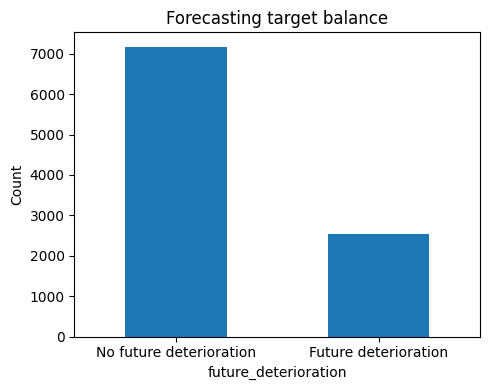

In [31]:
# ============================================================
# Inspect forecasting target balance
# ============================================================

target_counts = forecast_df["future_deterioration"].value_counts()

print(target_counts)

plt.figure(figsize=(5, 4))
target_counts.sort_index().plot(kind="bar")

plt.xticks(
    [0, 1],
    ["No future deterioration", "Future deterioration"],
    rotation=0
)

plt.ylabel("Count")
plt.title("Forecasting target balance")

plt.tight_layout()
plt.savefig(
    FIG_DIR / "forecasting_target_balance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

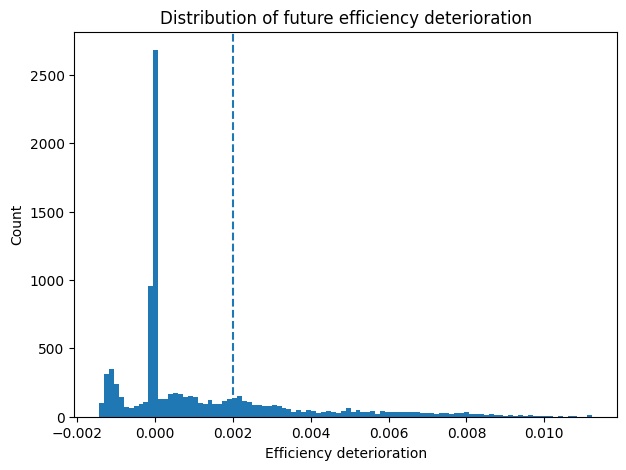

,future_efficiency_delta
count,9720.000000
mean,0.001251
std,0.002395
min,-0.001439
25%,-0.000047
50%,0.000051
75%,0.002120
max,0.011231


In [32]:
# ============================================================
# Inspect deterioration magnitude
# ============================================================

forecast_df["future_efficiency_delta"] = (
    forecast_df["weighted_efficiency"]
    - forecast_df["future_weighted_efficiency"]
)

plt.figure(figsize=(7,5))

plt.hist(
    forecast_df["future_efficiency_delta"],
    bins=100
)

plt.xlabel("Efficiency deterioration")
plt.ylabel("Count")
plt.title("Distribution of future efficiency deterioration")

plt.axvline(
    EFFICIENCY_DROP_THRESHOLD,
    linestyle="--"
)

plt.show()

forecast_df["future_efficiency_delta"].describe()

## 4. Forecasting model
Feature selection, train/test split, and logistic forecasting.

In [33]:
# ============================================================
# Select predictive features
# ============================================================

feature_cols = [

    # present accessibility organization
    "weighted_efficiency",
    "mean_r",
    "min_r",

    # temporal organization
    "time",
    "interval",
    "perturbation_density",

    # dynamical parameters
    "recovery_beta",
    "gamma",
    "decay"
]

# include noise if encoded numerically
if "noise" in forecast_df.columns:
    forecast_df["noise_numeric"] = (
        forecast_df["noise"].astype(int)
    )
    feature_cols.append("noise_numeric")

X = forecast_df[feature_cols].copy()

y = forecast_df["future_deterioration"]

print("Features:")
print(feature_cols)

print("\nShape X:", X.shape)
print("Shape y:", y.shape)

X.head()

Features:
['weighted_efficiency', 'mean_r', 'min_r', 'time', 'interval', 'perturbation_density', 'recovery_beta', 'gamma', 'decay', 'noise_numeric']

Shape X: (9720, 10)
Shape y: (9720,)


,weighted_efficiency,mean_r,min_r,time,interval,perturbation_density,recovery_beta,gamma,decay,noise_numeric
0,0.11653,1.0,1.0,0,4,0.25,0.012,0.168,0.004,0
1,0.11653,1.0,1.0,1,4,0.25,0.012,0.168,0.004,0
2,0.11653,1.0,1.0,2,4,0.25,0.012,0.168,0.004,0
3,0.11653,1.0,1.0,3,4,0.25,0.012,0.168,0.004,0
4,0.11653,1.0,1.0,4,4,0.25,0.012,0.168,0.004,0


In [34]:
# ============================================================
# Temporal train-test split
# ============================================================

split_idx = int(len(forecast_df) * 0.7)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain target balance")
print(y_train.value_counts(normalize=True))

print("\nTest target balance")
print(y_test.value_counts(normalize=True))

Train size: 6804
Test size: 2916

Train target balance
future_deterioration
0    0.737654
1    0.262346
Name: proportion, dtype: float64

Test target balance
future_deterioration
0    0.737997
1    0.262003
Name: proportion, dtype: float64


In [35]:
# ============================================================
# Logistic regression baseline
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Baseline model trained.")

Baseline model trained.


ROC-AUC: 0.971

Classification report
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      2152
           1       0.79      0.89      0.84       764

    accuracy                           0.91      2916
   macro avg       0.87      0.90      0.89      2916
weighted avg       0.91      0.91      0.91      2916



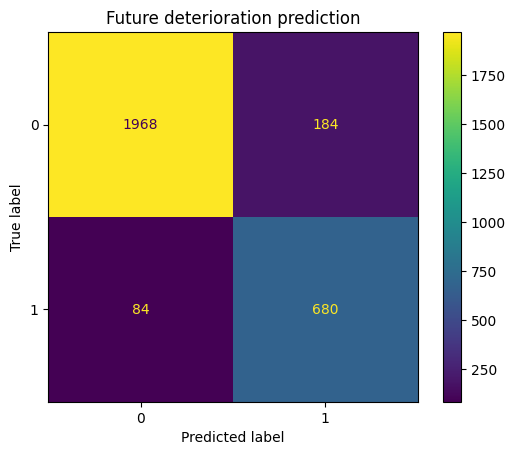

In [36]:
# ============================================================
# Evaluate forecasting performance
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 3))

print("\nClassification report")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Future deterioration prediction")
plt.show()

## 5. Ablation and predictive structure
Assess what operational variables carry predictive signal.

In [37]:
# ============================================================
# Ablation experiments
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

feature_sets = {

    "all_features": feature_cols,

    "without_time": [
        c for c in feature_cols
        if c != "time"
    ],

    "without_efficiency": [
        c for c in feature_cols
        if c != "weighted_efficiency"
    ],

    "minimal_dynamics": [
        "mean_r",
        "min_r",
        "interval",
        "perturbation_density",
        "recovery_beta",
        "gamma",
        "decay"
    ]
}

results = {}

for name, cols in feature_sets.items():

    X_local = forecast_df[cols]

    split_idx = int(len(X_local) * 0.7)

    X_train = X_local.iloc[:split_idx]
    X_test = X_local.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, probs)

    results[name] = auc

print(results)

{'all_features': np.float64(0.9713319157632495), 'without_time': np.float64(0.9717923422020669), 'without_efficiency': np.float64(0.9684331146966658), 'minimal_dynamics': np.float64(0.9688023073629305)}


In [38]:
# ============================================================
# Inspect predictive structure for each feature set
# ============================================================

coef_tables = {}

for name, cols in feature_sets.items():

    X_local = forecast_df[cols]

    split_idx = int(len(X_local) * 0.7)

    X_train = X_local.iloc[:split_idx]
    X_test = X_local.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    local_model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    local_model.fit(X_train, y_train)

    coef_df = pd.DataFrame({
        "feature": cols,
        "coefficient": local_model.named_steps["classifier"].coef_[0]
    })

    coef_df["abs_coef"] = np.abs(coef_df["coefficient"])

    coef_df = coef_df.sort_values(
        "abs_coef",
        ascending=False
    )

    coef_tables[name] = coef_df

    print("\n" + "="*60)
    print(name)
    display(coef_df)


all_features


,feature,coefficient,abs_coef
0,weighted_efficiency,5.795528,5.795528
3,time,-3.537770,3.537770
4,interval,-1.107340,1.107340
1,mean_r,1.025451,1.025451
5,perturbation_density,-0.885099,0.885099
8,decay,-0.423984,0.423984
7,gamma,0.423984,0.423984
6,recovery_beta,-0.423984,0.423984
2,min_r,0.138832,0.138832
9,noise_numeric,0.000000,0.000000



without_time


,feature,coefficient,abs_coef
1,mean_r,6.498790,6.498790
0,weighted_efficiency,3.074750,3.074750
3,interval,-1.272169,1.272169
4,perturbation_density,-1.202762,1.202762
6,gamma,0.748171,0.748171
5,recovery_beta,-0.748171,0.748171
7,decay,-0.748171,0.748171
2,min_r,0.042457,0.042457
8,noise_numeric,0.000000,0.000000



without_efficiency


,feature,coefficient,abs_coef
0,mean_r,5.816832,5.816832
2,time,-4.335028,4.335028
4,perturbation_density,-1.035287,1.035287
3,interval,-0.778740,0.778740
1,min_r,0.378563,0.378563
6,gamma,0.351572,0.351572
7,decay,-0.351572,0.351572
5,recovery_beta,-0.351572,0.351572
8,noise_numeric,0.000000,0.000000



minimal_dynamics


,feature,coefficient,abs_coef
0,mean_r,9.417528,9.417528
3,perturbation_density,-1.136653,1.136653
2,interval,-1.128258,1.128258
5,gamma,0.687837,0.687837
6,decay,-0.687837,0.687837
4,recovery_beta,-0.687837,0.687837
1,min_r,0.178366,0.178366


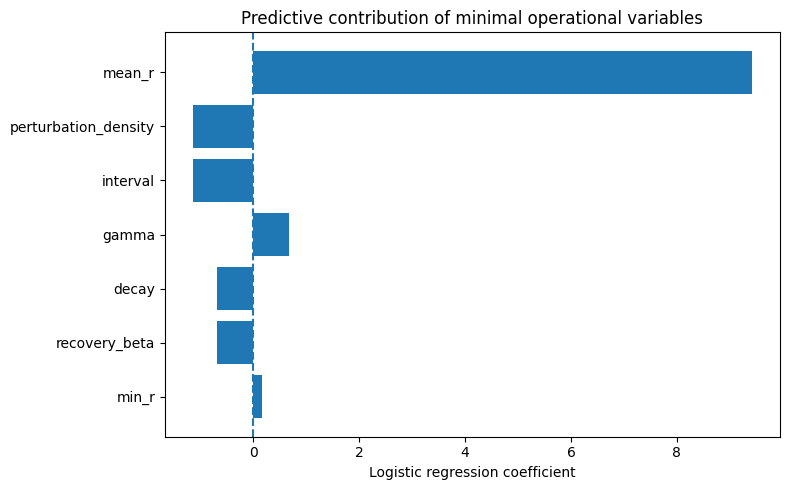

In [39]:
# ============================================================
# Plot coefficients for minimal dynamics model
# ============================================================

coef_df = coef_tables["minimal_dynamics"]

plt.figure(figsize=(8, 5))

plt.barh(
    coef_df["feature"],
    coef_df["coefficient"]
)

plt.axvline(0, linestyle="--")

plt.title("Predictive contribution of minimal operational variables")
plt.xlabel("Logistic regression coefficient")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Minimal recoverability state baseline
Test whether mean recoverability alone forecasts deterioration.

In [40]:
# ============================================================
# Mean_r only baseline
# ============================================================

single_feature = ["mean_r"]

X_local = forecast_df[single_feature]

split_idx = int(len(X_local) * 0.7)

X_train = X_local.iloc[:split_idx]
X_test = X_local.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

mean_r_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

mean_r_model.fit(X_train, y_train)

y_prob = mean_r_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC using mean_r only:", auc)

ROC-AUC using mean_r only: 0.9302380958173574


## 7. Permutation importance
Estimate operational contribution to predictive performance.

In [41]:
# ============================================================
# Permutation importance
# ============================================================

from sklearn.inspection import permutation_importance

# Use minimal dynamics model
cols = feature_sets["minimal_dynamics"]

X_local = forecast_df[cols]

split_idx = int(len(X_local) * 0.7)

X_train = X_local.iloc[:split_idx]
X_test = X_local.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

perm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

perm_model.fit(X_train, y_train)

# Permutation importance
perm_result = permutation_importance(
    perm_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": cols,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

display(importance_df)

,feature,importance_mean,importance_std
0,mean_r,0.425495,0.010736
5,gamma,0.009423,0.000664
6,decay,0.009423,0.000664
4,recovery_beta,0.009423,0.000664
2,interval,0.006009,0.000872
1,min_r,0.000066,0.000110
3,perturbation_density,-0.000044,0.000094


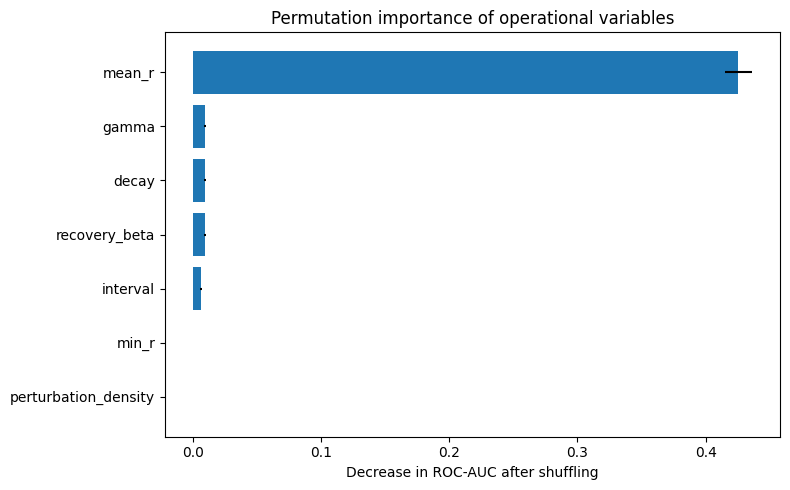

In [42]:
# ============================================================
# Plot permutation importance
# ============================================================

plt.figure(figsize=(8,5))

plt.barh(
    importance_df["feature"],
    importance_df["importance_mean"],
    xerr=importance_df["importance_std"]
)

plt.gca().invert_yaxis()

plt.xlabel("Decrease in ROC-AUC after shuffling")
plt.title("Permutation importance of operational variables")

plt.tight_layout()
plt.show()

## 8. Structural mapping falsation
Test prediction without direct operational state variables.

In [43]:
# ============================================================
# Forecasting without direct recoverability-state summaries
# ============================================================

reduced_cols = [
    "interval",
    "perturbation_density",
    "recovery_beta",
    "gamma",
    "decay"
]

X_local = forecast_df[reduced_cols]

split_idx = int(len(X_local) * 0.7)

X_train = X_local.iloc[:split_idx]
X_test = X_local.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

reduced_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

reduced_model.fit(X_train, y_train)

y_prob = reduced_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC without direct state variables:", auc)

ROC-AUC without direct state variables: 0.4415082037408279


## 9. Model comparison
Compare geometry, operational state, minimal model, and full model.

In [44]:
# ============================================================
# Final model comparison
# ============================================================

model_results = pd.DataFrame({

    "model": [
        "Geometry only",
        "Mean recoverability state",
        "Minimal operational model",
        "All features"
    ],

    "roc_auc": [
        0.4415082037408279,
        0.9302380958173574,
        0.9688023073629305,
        0.9713319157632495
    ],

    "interpretation": [
        "Poor forecastability",
        "Strong compressed-state signal",
        "Strong operational forecastability",
        "Minimal gain beyond operational model"
    ]
})

display(model_results)

model_results.to_csv(
    DATA_DIR / "forecasting_model_comparison.csv",
    index=False
)

,model,roc_auc,interpretation
0,Geometry only,0.441508,Poor forecastability
1,Mean recoverability state,0.930238,Strong compressed-state signal
2,Minimal operational model,0.968802,Strong operational forecastability
3,All features,0.971332,Minimal gain beyond operational model


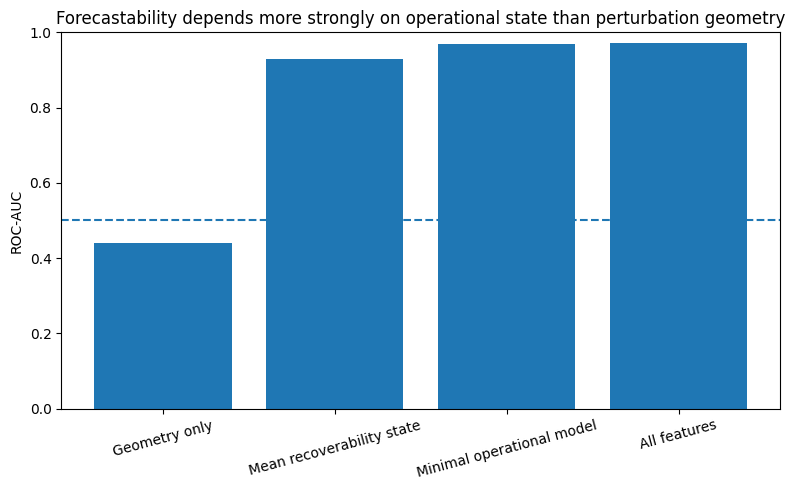

In [45]:
# ============================================================
# ROC-AUC comparison figure
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    model_results["model"],
    model_results["roc_auc"]
)

plt.ylim(0,1)

plt.ylabel("ROC-AUC")

plt.title(
    "Forecastability depends more strongly on operational state than perturbation geometry"
)

plt.xticks(rotation=15)

plt.axhline(
    0.5,
    linestyle="--"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "forecasting_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Shuffle falsation control
Randomize labels to test non-artifactual signal.

In [46]:
# ============================================================
# Shuffle-target falsation control
# ============================================================

# This control breaks the relationship between present operational
# observables and future deterioration labels. If the predictive signal
# is non-artifactual, performance should collapse toward chance level.

X_shuffle = forecast_df[feature_sets["minimal_dynamics"]].copy()
y_shuffle = forecast_df["future_deterioration"].copy()

# Randomize labels globally
rng = np.random.default_rng(42)
y_shuffle_random = pd.Series(
    rng.permutation(y_shuffle.values),
    index=y_shuffle.index
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_shuffle,
    y_shuffle_random,
    test_size=0.30,
    random_state=42,
    stratify=y_shuffle_random
)

shuffle_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

shuffle_model.fit(X_train_s, y_train_s)

y_prob_s = shuffle_model.predict_proba(X_test_s)[:, 1]

shuffle_auc = roc_auc_score(y_test_s, y_prob_s)

print(f"Shuffle-target ROC-AUC: {shuffle_auc:.3f}")

Shuffle-target ROC-AUC: 0.495


## 11. Forecast horizon sensitivity
Test robustness across prediction horizons.

In [47]:
# ============================================================
# Forecast horizon sensitivity
# ============================================================

forecast_horizons = [10, 20, 30, 40]

horizon_results = []

for horizon in forecast_horizons:

    temp_df = temporal_df.copy()

    temp_df["future_weighted_efficiency"] = (
        temp_df
        .groupby("simulation_id")["weighted_efficiency"]
        .shift(-horizon)
    )

    temp_df["future_deterioration"] = (
        (
            temp_df["weighted_efficiency"]
            - temp_df["future_weighted_efficiency"]
        )
        > 0.002
    ).astype(int)

    temp_df = (
        temp_df
        .dropna()
        .reset_index(drop=True)
    )

    X_local = temp_df[
        feature_sets["minimal_dynamics"]
    ]

    y_local = temp_df[
        "future_deterioration"
    ]

    split_idx = int(len(X_local)*0.7)

    X_train = X_local.iloc[:split_idx]
    X_test = X_local.iloc[split_idx:]

    y_train = y_local.iloc[:split_idx]
    y_test = y_local.iloc[split_idx:]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train, y_train)

    probs = model.predict_proba(
        X_test
    )[:,1]

    auc = roc_auc_score(
        y_test,
        probs
    )

    horizon_results.append({
        "forecast_horizon": horizon,
        "roc_auc": auc
    })

horizon_results = pd.DataFrame(
    horizon_results
)

display(horizon_results)

,forecast_horizon,roc_auc
0,10,0.980256
1,20,0.968802
2,30,0.970284
3,40,0.963182


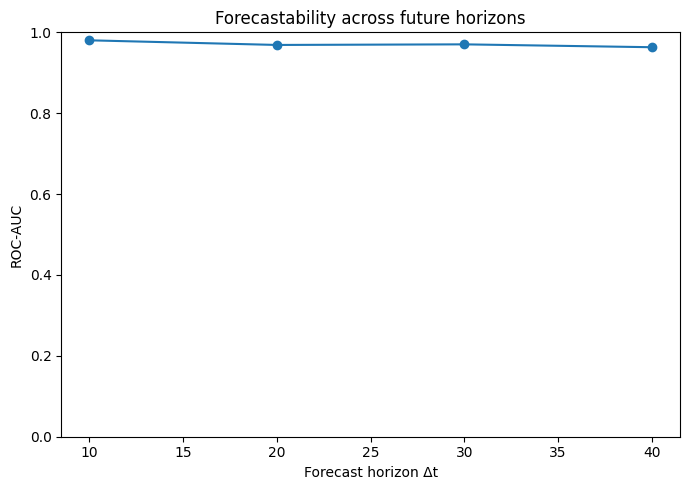

In [48]:
# ============================================================
# Horizon sensitivity figure
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(
    horizon_results["forecast_horizon"],
    horizon_results["roc_auc"],
    marker="o"
)

plt.ylim(0,1)

plt.xlabel("Forecast horizon Δt")
plt.ylabel("ROC-AUC")

plt.title(
    "Forecastability across future horizons"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "forecast_horizon_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

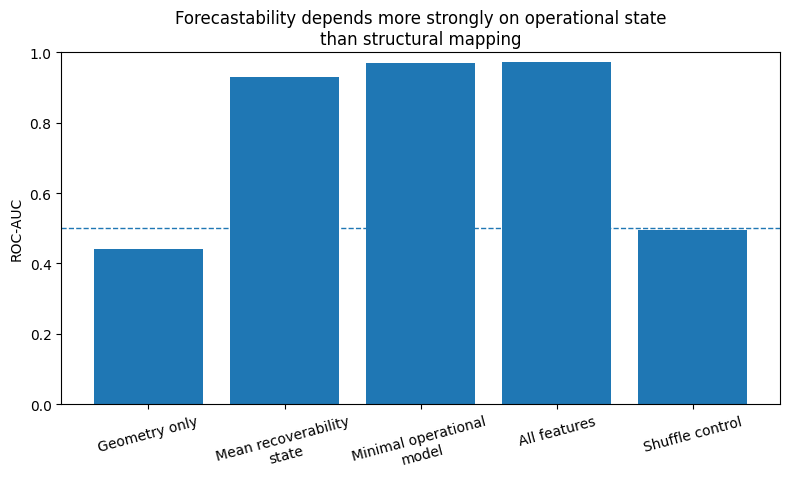

In [49]:
# ============================================================
# Final forecasting summary figure
# ============================================================

summary_results = {
    "Geometry only": 0.4415082037408279,
    "Mean recoverability\nstate": 0.9302380958173574,
    "Minimal operational\nmodel": 0.9688023073629305,
    "All features": 0.9713319157632495,
    "Shuffle control": shuffle_auc
}

plt.figure(figsize=(8,5))

plt.bar(
    list(summary_results.keys()),
    list(summary_results.values())
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1
)

plt.ylabel("ROC-AUC")

plt.title(
    "Forecastability depends more strongly on operational state\nthan structural mapping"
)

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "forecastability_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Interpretation
Forecastability and operational accessibility.

## Forecastability of accessibility deterioration

Structural perturbation geometry alone does not appear sufficient to forecast future deterioration (ROC-AUC ≈ 0.44).

In contrast, operational state observables retain strong predictive signal (ROC-AUC ≈ 0.93–0.97), suggesting that future accessibility organization may depend more strongly on recoverability state than on perturbation geometry alone.

Minimal operational variables recover nearly the full predictive signal, while shuffle-target controls collapse prediction toward chance level (ROC-AUC ≈ 0.50), consistent with non-artifactual signal.

These results are consistent with the interpretation that operational accessibility may behave more like routing than mapping: the structural scaffold may persist while future reachability reorganizes dynamically.